In [1]:
from neuron import h#, gui
import numpy as np
import networkx as nx
import pygraphviz as gv
import yaml
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

from general_utils import circle
from analysis import get_dsgc_img

In [2]:
# %matplotlib notebook
# %matplotlib widget
%matplotlib ipympl
# %matplotlib qt
plt.rcParams.update({"figure.max_open_warning": 0})
plt.rcParams['svg.fonttype'] = 'none'  # don't save font as paths (assumes font present on machine)

In [3]:
_ = h.load_file("RGCmodelGD.hoc")
RGC = h.DSGC(0, 0)
soma = RGC.soma
all_dends = RGC.dend

def dsgc_digraph(rgc):
    """Node indices correspond to (dend index + 1) as the soma is the 0th node. e.g. RGC.dend[0] is node 1
    on the graph."""
    g = nx.DiGraph()
    secs = [rgc.soma] + [d for d in rgc.dend]  # soma takes 0th position, offseting all dends by 1
    edges = []
    for i, parent in enumerate(secs):
        parent_ref = h.SectionRef(parent)
        for j in range(parent_ref.nchild()):
            child = parent_ref.child[j]
            # dend names are formated as "DSGC[1].dend[17]" and the id corresponds to the index
            # in the rgc.dend list of all dendrites
            cid = int(child.name().split(".")[1][5:-1]) + 1  # offset to accomodate 0th soma node
            edges.append((i, cid))
    g.add_edges_from(edges)
    return g

def rec_dist_graph(rgc):
    """Graph of recording locations, nodes for locations 0.5 and 1.0 correspond to rgc.dend[N] and N+1."""
    g = nx.Graph()
    edges = []
    
    # prime dends are 1, 24, 35. 1 and 24 are connected to soma(1), and 35 to soma(0)
    def add_prime_edge(a, b):
        edges.append((a * 2, b * 2, h.distance(rgc.dend[a](0.5), rgc.dend[b](0.5))))
    add_prime_edge(1, 24)
    add_prime_edge(35, 1)
    add_prime_edge(35, 24)
    
    secs = [d for d in rgc.dend]  # soma takes 0th position, offseting all dends by 1
    for i, parent in enumerate(secs):
        parent_ref = h.SectionRef(parent)
        edges.append((i * 2, i * 2 + 1, h.distance(parent(0.5), parent(1.0))))
        for j in range(parent_ref.nchild()):
            child = parent_ref.child[j]
            # dend names are formated as "DSGC[1].dend[17]" and the id corresponds to the index
            # in the rgc.dend list of all dendrites
            cid = int(child.name().split(".")[1][5:-1]) 
            edges.append((i * 2 + 1, cid * 2, h.distance(parent(1.0), child(0.5))))
    g.add_weighted_edges_from(edges)
    return g

dg = rec_dist_graph(RGC)
di_dsgc = dsgc_digraph(RGC)
rec_dists = np.loadtxt("rec_dist_matrix.csv")

In [4]:
ego = nx.generators.ego_graph(dg, 0, radius=50, distance="weight")

In [5]:
a_di_dsgc = nx.nx_agraph.to_agraph(di_dsgc)

In [6]:
a_di_dsgc.draw("directed_dsgc.svg", prog="neato")

In [7]:
nx.nx_agraph.to_agraph(ego).draw("dist_graph_test_ego.svg", prog="neato")

In [8]:
# checking against dist matrix
rr = np.random.default_rng()
wrong = 0
for _ in range(200):
    a, b = rr.integers(0, 300, size=2)
    gd = nx.shortest_path_length(dg, weight="weight", source=a, target=b)
    md = rec_dists[a, b]
    if gd != md:
        diff = gd - md
        # print("%.2f - %.2f = %.2f" % (gd, md, diff))
        if abs(diff) > 2:
            wrong += 1
print("%i wrong" % wrong)

0 wrong


In [9]:
list(dg.neighbors(35))

[34, 168, 36]

In [10]:
all_dends[343].x3d(0)

27.2460994720459

In [11]:
soma.x3d(0)

104.58999633789062

In [12]:
list(di_dsgc.neighbors(2))

[18, 3]

In [13]:
yaml_file = "directed_dsgc.yaml" 
with open(yaml_file, mode="w") as fd:
    yaml.dump(di_dsgc, fd)

In [14]:
with open(yaml_file, mode="r") as fd:
    loaded_di_dsgc = yaml.load(fd, Loader=yaml.Loader)

In [15]:
list(di_dsgc.neighbors(2))

[18, 3]

In [16]:
list(loaded_di_dsgc.neighbors(2))

[3, 18]

In [17]:
wrong = 0
for i in range(300):
    if set(di_dsgc.neighbors(i)) != set(loaded_di_dsgc.neighbors(i)):
        wrong += 1
print("%i wrong" % wrong)

0 wrong


In [21]:
get_pts = lambda sec: np.array([[sec.x3d(i), sec.y3d(i), sec.z3d(i), sec.diam3d(i)] for i in range(sec.n3d())])
    
soma_pts = get_pts(soma)
soma_pts = np.concatenate([circle(pt[3]/2, fn=6).T + pt[:2].reshape(1, -1) for pt in soma_pts], axis=0)
hullvs = ConvexHull(soma_pts[:, :2]).vertices
soma_hull = np.array([soma_pts[v] for v in hullvs])
soma_hull_closed = np.r_[soma_hull, soma_hull[0].reshape(1, -1)]
sec_pts = [soma_hull_closed]
for sec in all_dends:
    sec_pts.append(get_pts(sec))

Possible solutions for scaling the dendrites by their diameter:

https://stackoverflow.com/questions/19394505/expand-the-line-with-specified-width-in-data-unit

https://stackoverflow.com/questions/61252250/matplotlib-patches-pathpatch-with-the-linewidth-given-in-data-units-not-point

(10.0, 230.0)

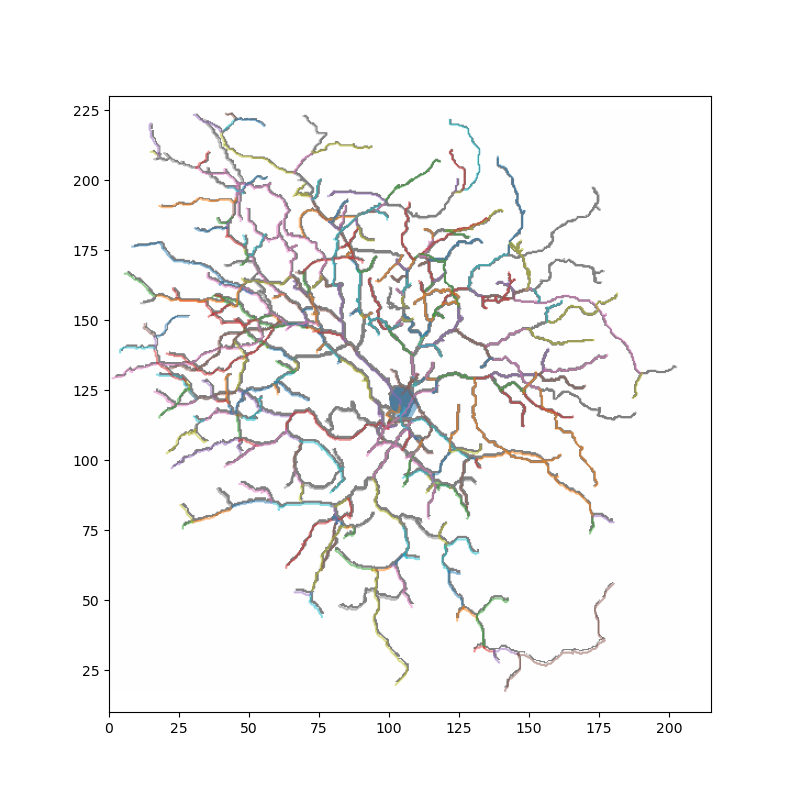

In [27]:
dsgc_paths_fig, dsgc_paths_ax = plt.subplots(1, figsize=(8, 8))

dsgc_img, extent = get_dsgc_img()
dsgc_paths_ax.imshow(dsgc_img, extent=extent, alpha=0.5, cmap="gray")

offset_x = 0
offset_y = 0
dsgc_paths_ax.fill(sec_pts[0][:, 0] + offset_x, sec_pts[0][:, 1] + offset_y, alpha=0.5)
for pts in sec_pts[1:]:
    dsgc_paths_ax.plot(pts[:, 0] + offset_x, pts[:, 1] + offset_y, alpha=0.5)
    
dsgc_paths_ax.set_xlim(0, 215)
dsgc_paths_ax.set_ylim(10, 230)